In [ ]:
!nvidia-smi

Fri May  2 04:18:02 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
!pip install python-multipart -q
!pip install FastAPI -q
!pip install uvicorn -q
!pip install kaleido -q
!pip install ultralytics -q
!pip install -q -U google-generativeai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/1

In [ ]:
from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics 8.3.123 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.4/112.6 GB disk)


In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

!pip install roboflow --quiet

from roboflow import Roboflow
rf = Roboflow(api_key="MvaXK911emNaQHyxdbXZ")
project = rf.workspace("dataset-lmrsw").project("compdetect")
dataset = project.version(23).download("yolov8")



/content/datasets
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.3/85.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 57.3 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to CompDetect-23 in yolov8:: 100%|██████████| 1176/1176 [00:00<00:00, 8659.13it/s]


In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8n.pt data={dataset.location}/data.yaml epochs=100 imgsz=600 plots=True

/content
100% 6.25M/6.25M [00:00<00:00, 101MB/s]
Ultralytics 8.3.123 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/datasets/CompDetect-23/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=600, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=Fals

In [ ]:
!ls {HOME}/runs/detect/train/

args.yaml			 R_curve.png	      train_batch2.jpg
confusion_matrix_normalized.png  results.csv	      val_batch0_labels.jpg
confusion_matrix.png		 results.png	      val_batch0_pred.jpg
F1_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
labels_correlogram.jpg		 train_batch1.jpg     val_batch1_pred.jpg
labels.jpg			 train_batch2430.jpg  val_batch2_labels.jpg
P_curve.png			 train_batch2431.jpg  val_batch2_pred.jpg
PR_curve.png			 train_batch2432.jpg  weights


/content


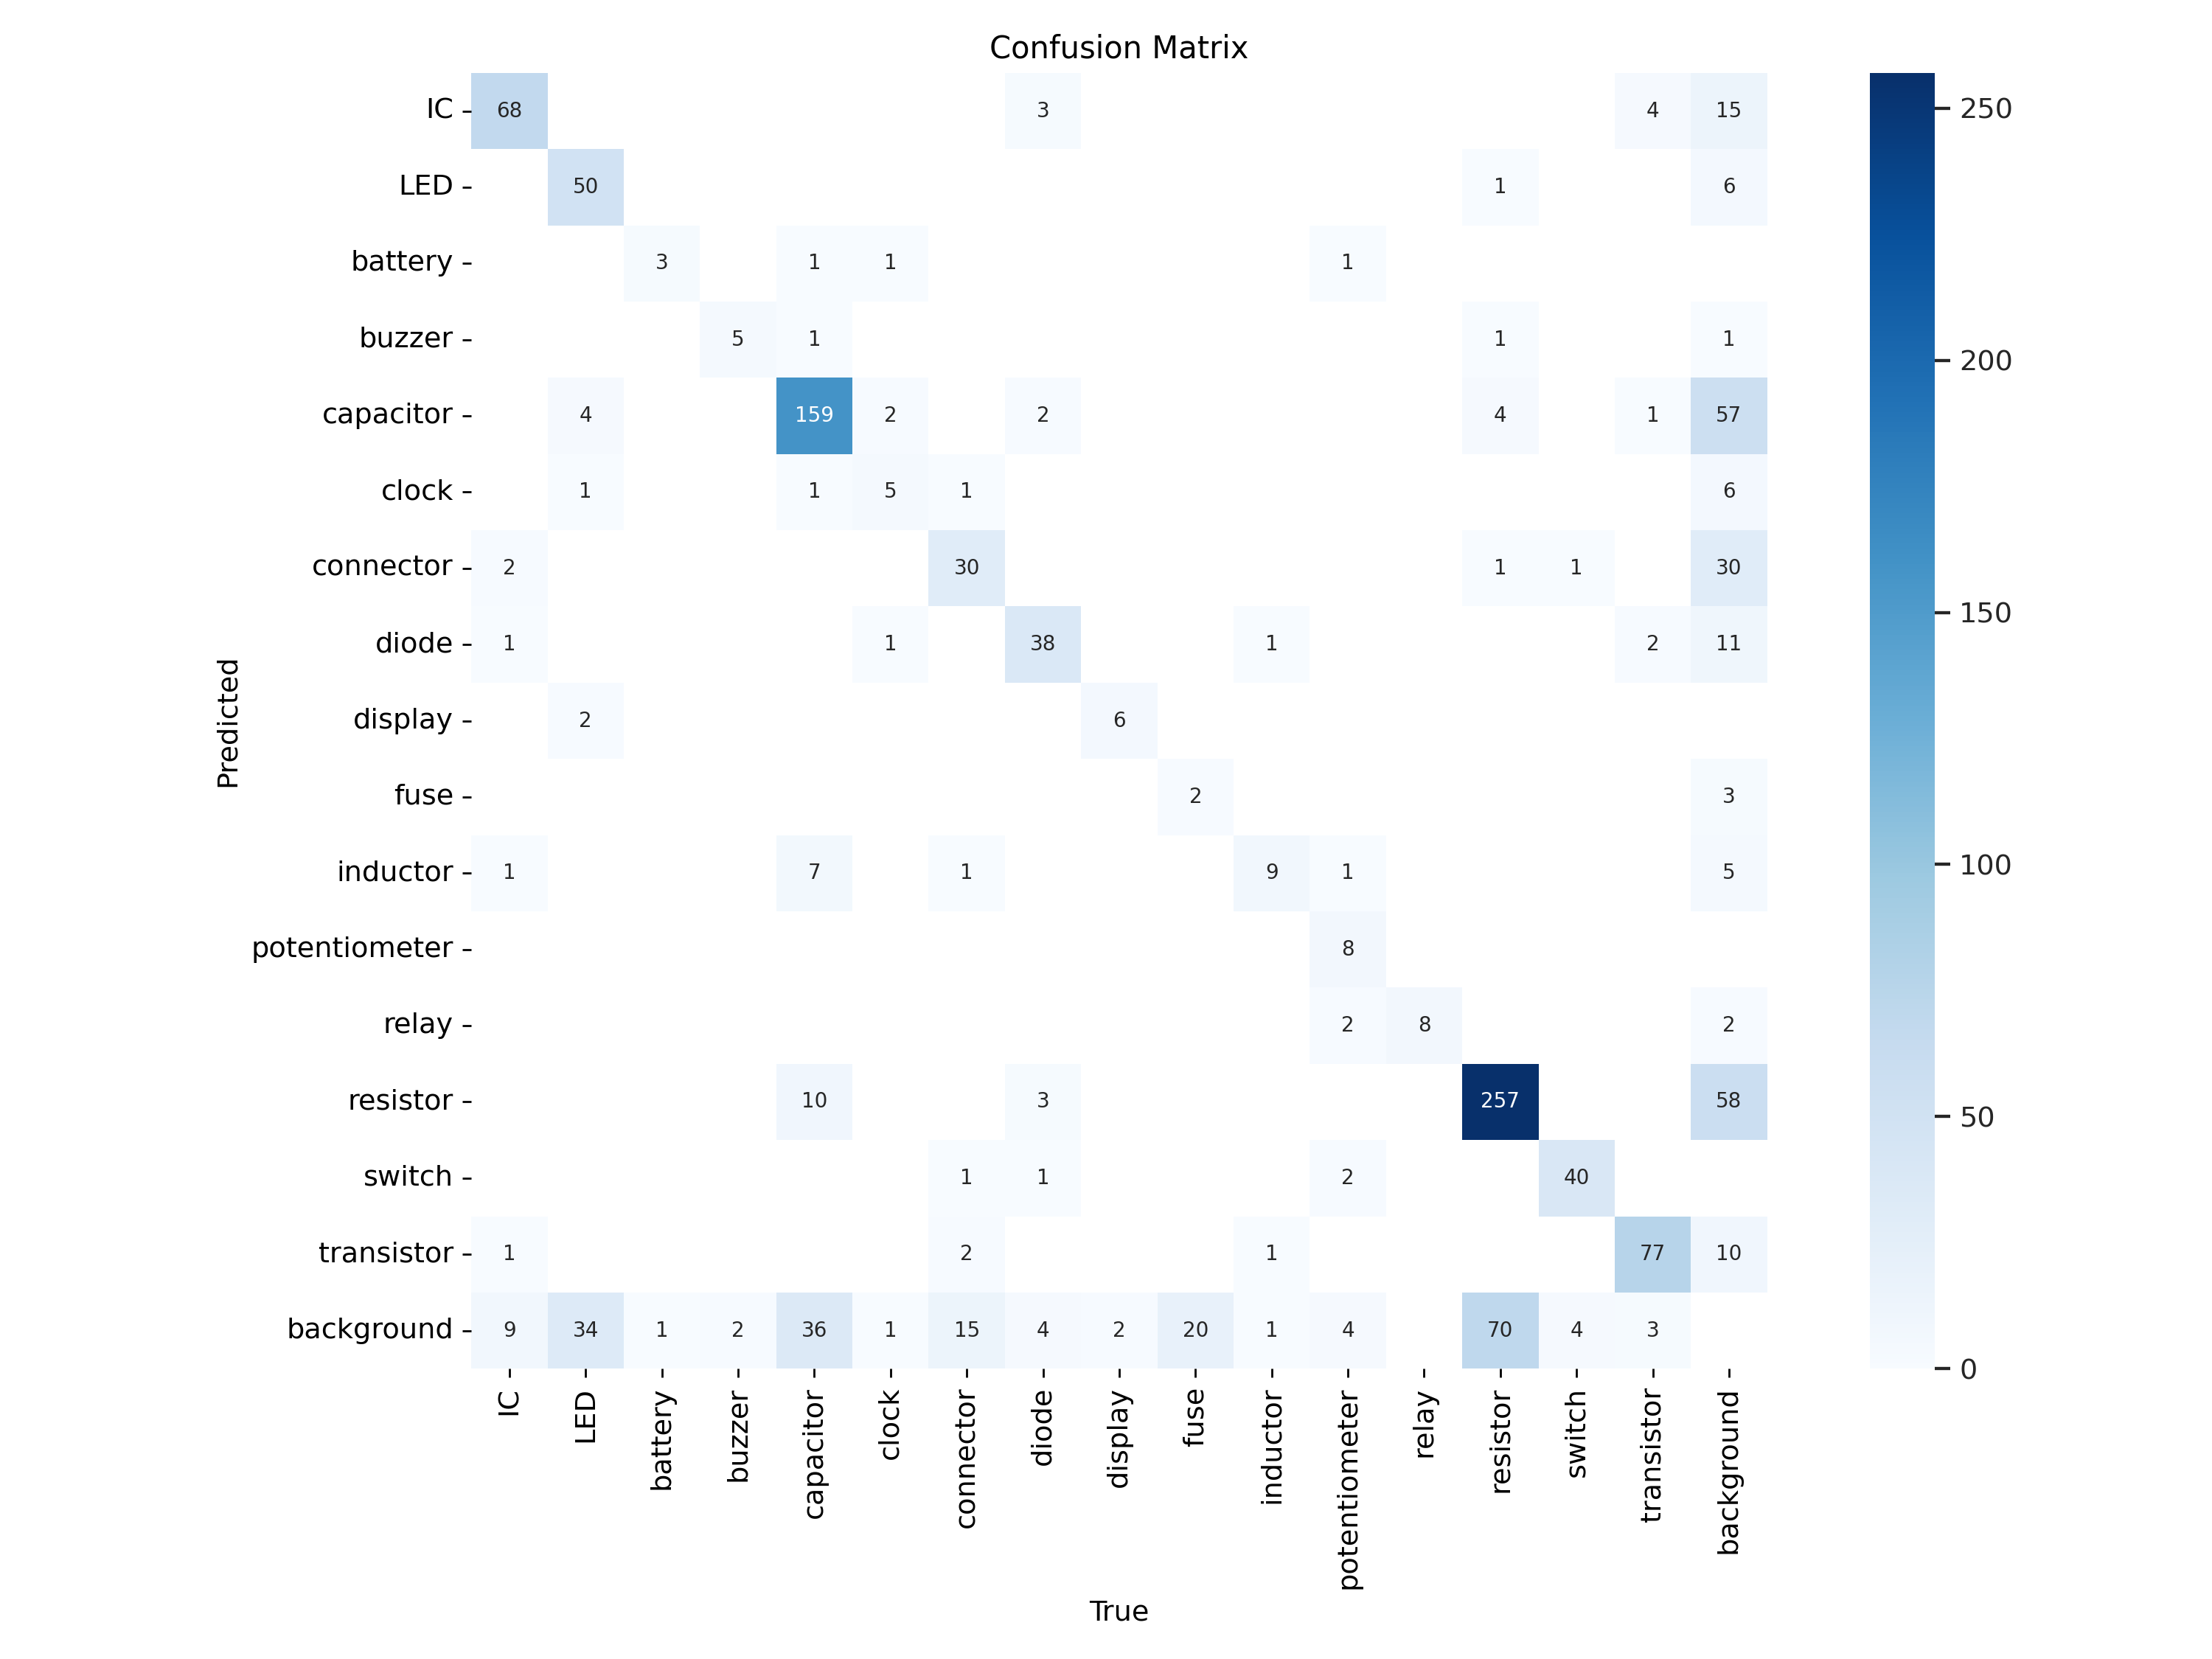

In [ ]:
%cd {HOME}
Image(filename=f'/content/runs/detect/train/confusion_matrix.png', width=600)

/content


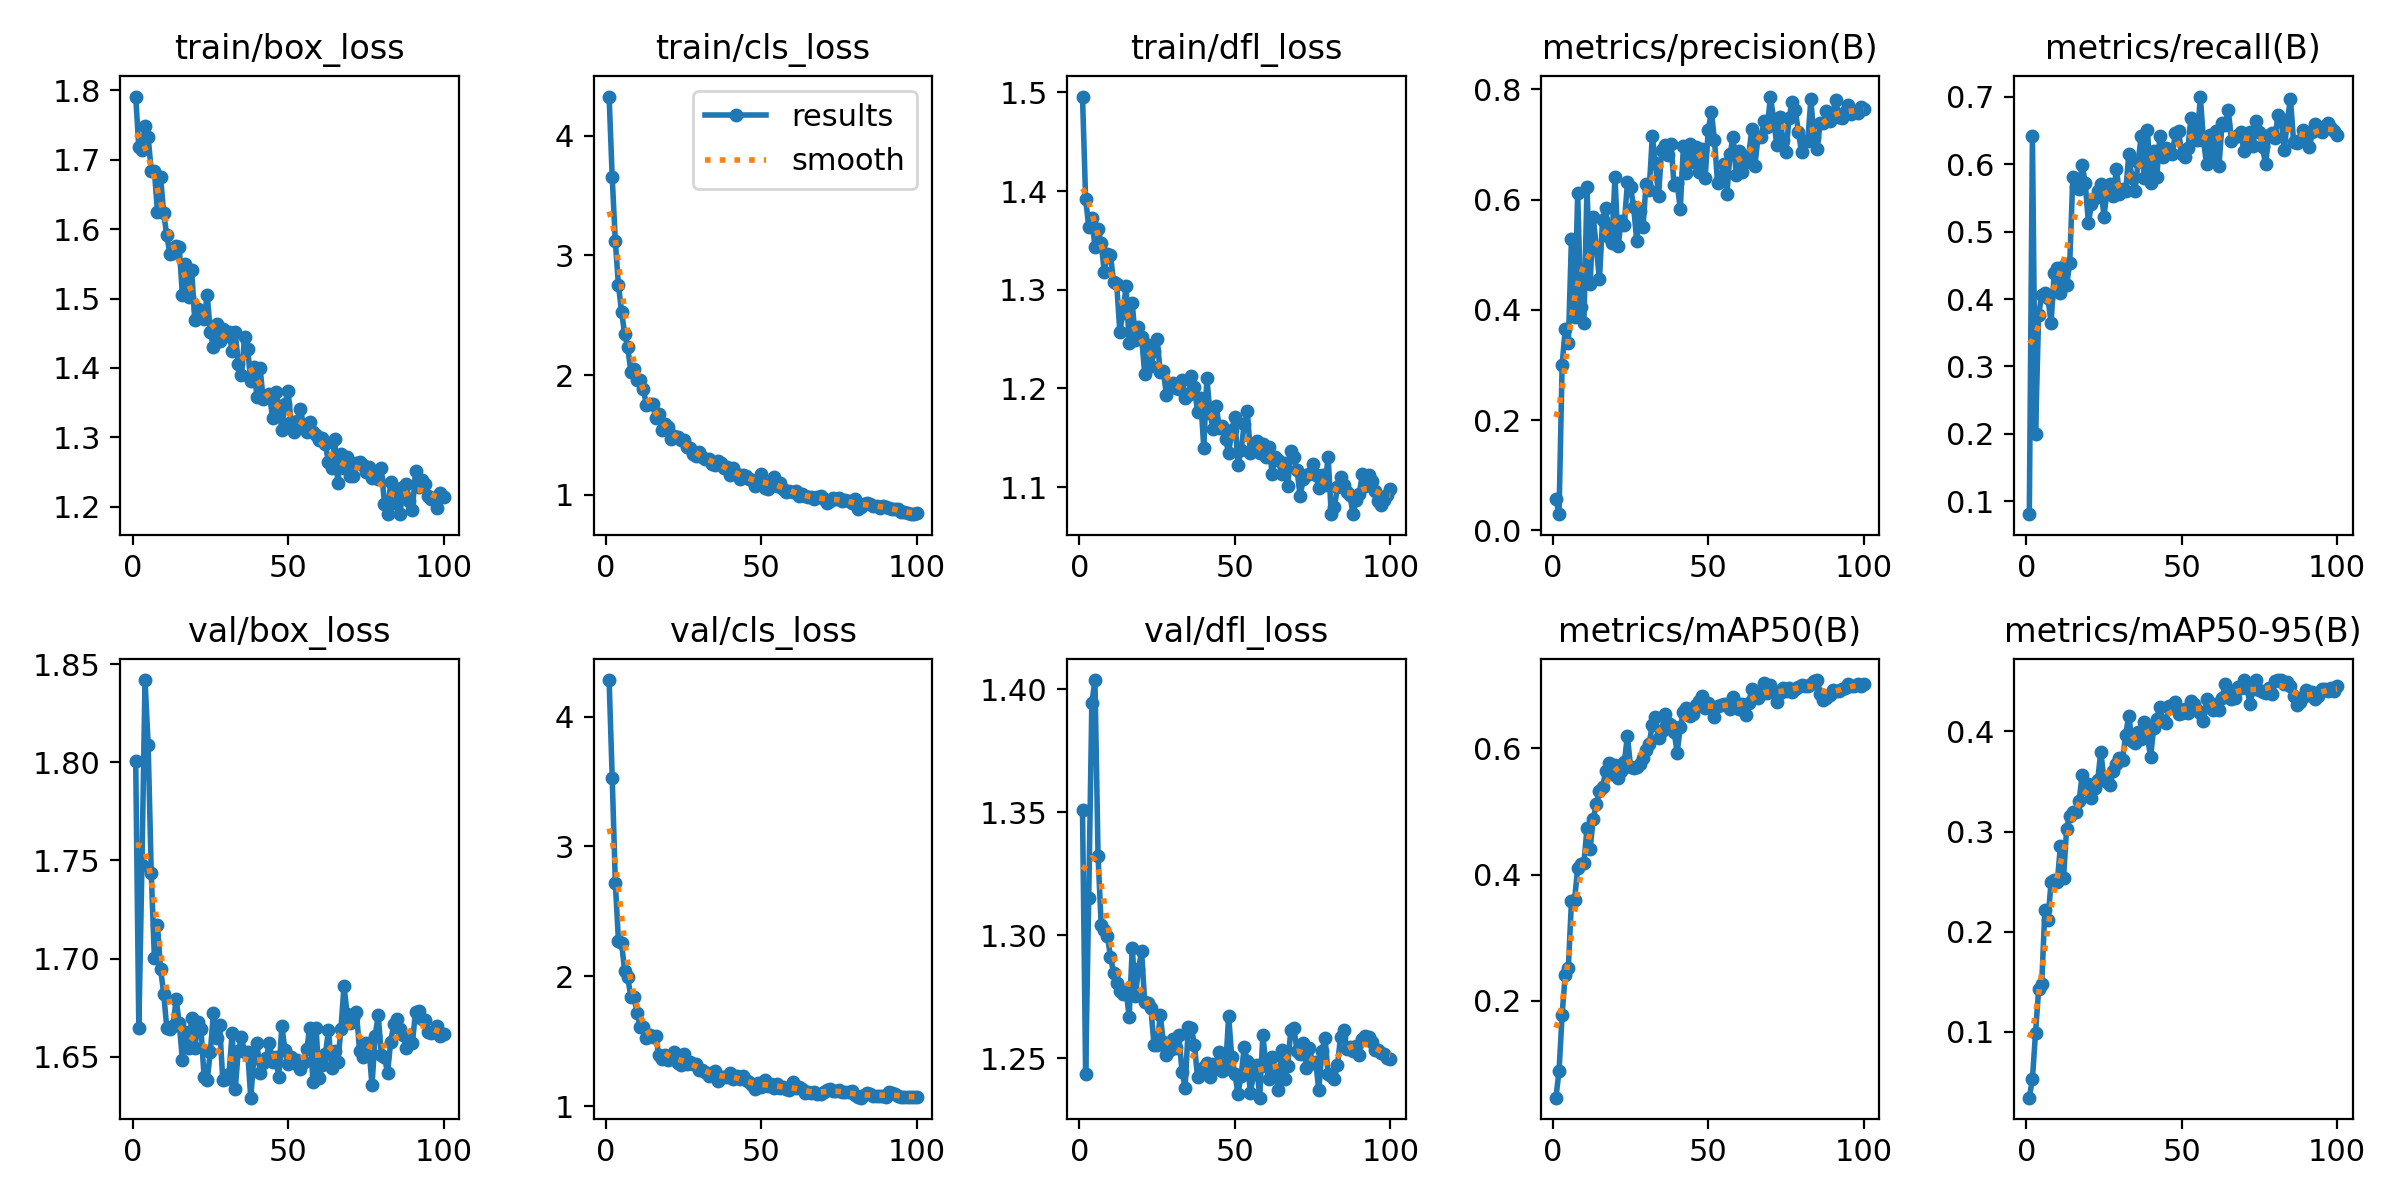

In [ ]:
%cd {HOME}
Image(filename=f'/content/runs/detect/train/results.png', width=600)

/content


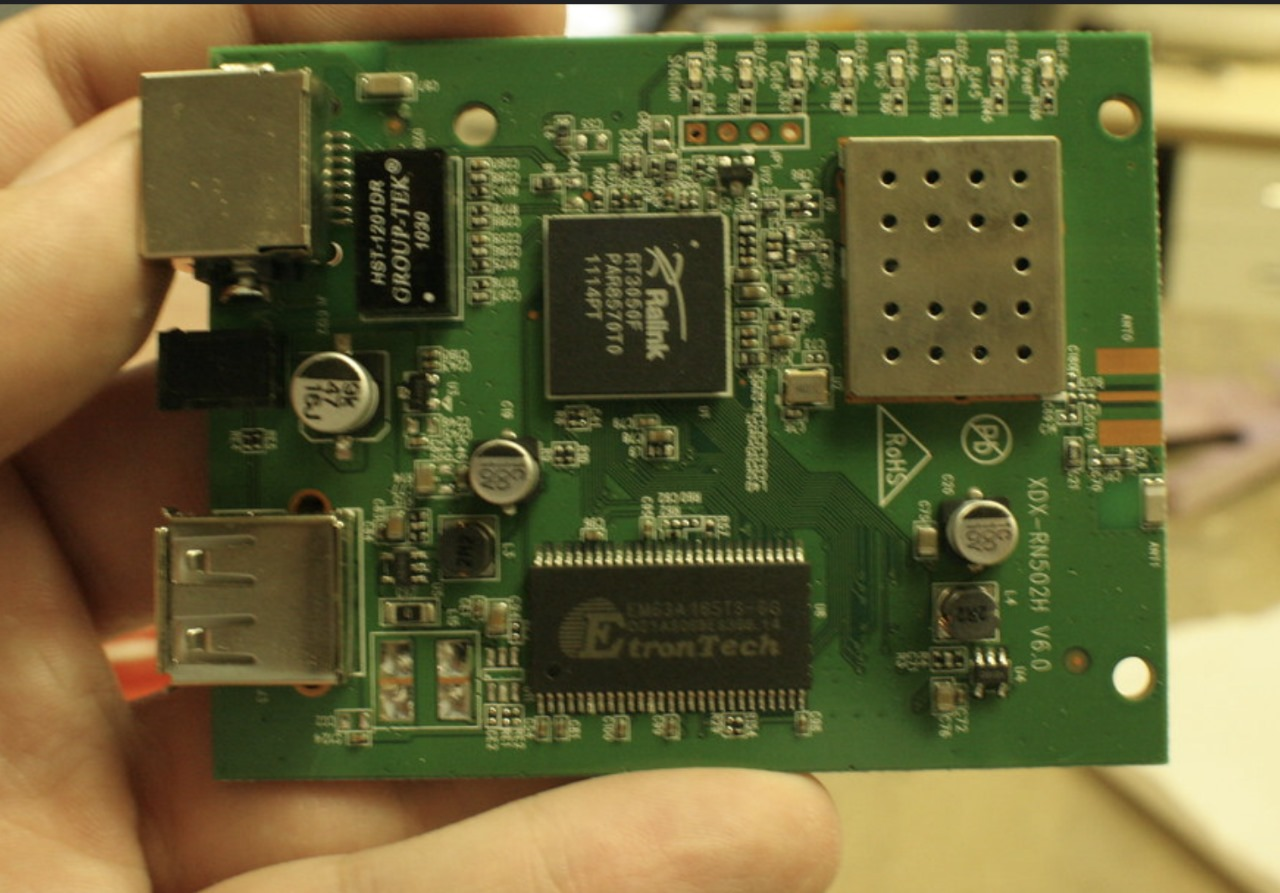

In [ ]:
%cd {HOME}
Image(filename=f'/content/microcontroller.jpeg', width=600)

In [ ]:
%cd {HOME}

!yolo task=detect mode=val model=/content/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

/content
Ultralytics 8.3.123 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,008,768 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1104.2±394.4 MB/s, size: 45.6 KB)
val: Scanning /content/datasets/CompDetect-23/valid/labels.cache... 76 images, 0 backgrounds, 0 corrupt: 100% 76/76 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 51, len(boxes) = 1044. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 5/5 [00:05<00:00,  1.20s/it]
                   all         76       1044      0.768      0.628      0.701      0.451
                    IC         45         82      0.831      0.817      0.836      0.553
                   LED         34    

In [ ]:
%cd {HOME}
!yolo task=detect mode=predict model=/content/runs/detect/train/weights/best.pt conf=0.25 source=/content/microcontroller.jpeg save=True

/content
Ultralytics 8.3.123 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,008,768 parameters, 0 gradients, 8.1 GFLOPs

image 1/1 /content/microcontroller.jpeg: 448x608 5 ICs, 3 LEDs, 10 capacitors, 2 connectors, 1 diode, 11 resistors, 39.1ms
Speed: 3.7ms preprocess, 39.1ms inference, 176.4ms postprocess per image at shape (1, 3, 448, 608)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


**NOTE:** Let's take a look at few results.

In [ ]:
import glob
from IPython.display import Image, display

for image_path in glob.glob('/content/runs/detect/predict/download.jpeg'):
      display(Image(filename=image_path, width=600))
      print("\n")

In [ ]:
!pip install -U -q "google"
!pip install -U -q "google.genai"

import os
from google.colab import userdata
from google.colab import drive
os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")

drive.mount("/content/drive")
os.chdir("/content/drive/MyDrive/Google AI Studio")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.4/164.4 kB 7.8 MB/s eta 0:00:00


ValueError: mount failed

In [ ]:
import os
import mimetypes
from google import genai
from google.genai import types
from google.genai.types import GenerationConfig


def save_binary_file(file_name, data):
    with open(file_name, "wb") as f:
        f.write(data)


def generate():
    client = genai.Client(
        api_key=os.environ.get("GEMINI_API_KEY"),
    )

    files = [
        client.files.upload(file="microcontroller.jpeg"),
    ]

    model = "gemini-2.0-flash-exp-image-generation"

    contents = [
        types.Content(
            role="user",
            parts=[
                types.Part.from_uri(
                    file_uri=files[0].uri,
                    mime_type=files[0].mime_type,
                ),
                types.Part.from_text(text="""
                perform ocr on it and then do the following:
                  Analyze this PCB component image and identify:
                    1. What type of component this is (resistor, capacitor, IC, etc.)
                    2. Any markings or labels visible
                    3. Potential functionality or what kind of board is it
                    4. Estimated confidence level (0-100%)
                  and then do the following
                    1. Component recognition
                    2. Debugging interface detection
                    3. Hardware security assessment

                    provide the output in a structured format (without #, * and everything)
                """),
            ],
        ),
        types.Content(
            role="user",
            parts=[
                types.Part.from_text(text="RESULTS"),
            ],
        ),
    ]

    generation_config = GenerationConfig(
        temperature=0.7,
        top_k=50,
        top_p=0.95,
        max_output_tokens=1024
    )

    generate_content_config = types.GenerateContentConfig(
        response_modalities=["image", "text"],
        response_mime_type="text/plain",
        generation_config=generation_config

    )

    for chunk in client.models.generate_content_stream(
        model=model,
        contents=contents,
        config=generate_content_config,
        generation_config=generation_config,
    ):
        if not chunk.candidates or not chunk.candidates[0].content or not chunk.candidates[0].content.parts:
            continue
        part = chunk.candidates[0].content.parts[0]
        if hasattr(part, "inline_data") and part.inline_data:
            file_name = "/content/runs/detect/predict/microcontroller.jpg"
            inline_data = part.inline_data
            file_extension = mimetypes.guess_extension(inline_data.mime_type)
            save_binary_file(f"{file_name}{file_extension}", inline_data.data)
            print(f"File of mime type {inline_data.mime_type} saved to: {file_name}{file_extension}")
        elif hasattr(part, "text") and part.text:
            print(part.text)


if __name__ == "__main__":
    generate()
